# A03 — Pilot Baseline Reproduction + Results

**Platform:** Kaggle Notebooks — 2x NVIDIA T4 GPUs  
**Author:** Kenneth Peter Fernandes  
**Course:** CISC-727: Advanced Research Explorations (ARE) - I  
**Date:** Spring 2026

## Environment Setup

In [1]:
import os
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed.fsdp import FullyShardedDataParallel as FSDP
from torch.distributed.fsdp import ShardingStrategy
from torch.utils.data import DataLoader, DistributedSampler
from torch.cuda.amp import GradScaler

import torchvision
import torchvision.transforms as transforms

# Environment info
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    print(f"    Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")
print(f"NCCL available: {torch.distributed.is_nccl_available()}")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU count: 2
  GPU 0: Tesla T4
    Memory: 15.6 GB
  GPU 1: Tesla T4
    Memory: 15.6 GB
NCCL available: True


## A02 Continuity

**Chosen Gap:** The literature on efficient attention demonstrates that FlashAttention achieves significant speedups over standard attention through IO-aware kernel optimization. However, existing benchmarks primarily evaluate FlashAttention in single-GPU or large-cluster settings. There is an underexplored gap in understanding how FlashAttention's compute-side advantage interacts with multi-GPU communication overhead — specifically whether the relative speedup is preserved, diminished, or eliminated as the communication burden increases across parallelization strategies.

**Closest Competitor:** FlashAttention-2 (Dao, 2023) — improves upon FlashAttention through better GPU work partitioning and occupancy, but evaluations focus on single-GPU kernel performance and large-scale end-to-end training, not on the interaction between kernel-level speedup and distributed training communication cost.

**Why It Matters:** Researchers with modest multi-GPU setups (2–8 GPUs) need evidence-based guidance on whether FlashAttention's speedup translates to meaningful end-to-end training improvements or whether communication overhead dominates total step time, reducing the kernel-level optimization's practical impact.

## Hypothesis + Prediction

**Hypothesis:** FlashAttention's relative speedup over standard attention diminishes as communication overhead increases when scaling from single-GPU to multi-GPU training.

**Predictions:**
- On a single GPU (no communication), FlashAttention will show its **maximum relative speedup** over standard attention.
- Under DDP (low communication — all-reduce after backward), the speedup will be **partially preserved** because communication is modest relative to compute.
- Under FSDP (high communication — all-gather per layer + reduce-scatter), the speedup will **shrink further** because communication becomes a larger fraction of total step time.

**What Would Refute It:** If FlashAttention's relative speedup (%) remains constant or increases from single-GPU → DDP → FSDP, the hypothesis is rejected.

## PCAM + Work–Depth Analysis

### PCAM Framing

**Partitioning:** The training workload is partitioned along the data dimension. Each GPU receives an equal shard of the mini-batch (64 samples per GPU). The model computation (forward, backward) is replicated on each GPU for DDP, or the model parameters are sharded across GPUs for FSDP. The attention computation within each layer is not partitioned — each GPU computes full attention on its data shard.

**Communication:** 
- *DDP:* All-reduce of gradients at the end of backward pass. Communication volume = model size × 2 (reduce + broadcast). Occurs once per step.
- *FSDP:* All-gather of parameters before each layer's forward pass + reduce-scatter of gradients after each layer's backward pass. Communication volume scales with number of layers × parameter size per layer. Occurs multiple times per step.

**Agglomeration:** Gradients are bucketed (grouped into larger tensors) before all-reduce in DDP to reduce the number of communication calls and improve bandwidth utilization. In FSDP, parameter shards are gathered at the granularity of FSDP wrapping units (typically per-layer).

**Mapping:** 2 GPUs on a single Kaggle node connected via PCIe. Each GPU is mapped one process (rank 0, rank 1). Data shards are assigned via DistributedSampler.

### Work–Depth Analysis

**Total Work (W):** The total compute across all GPUs remains approximately constant regardless of parallelization strategy. Each GPU processes half the batch, so total FLOPs ≈ single-GPU FLOPs. FlashAttention reduces the constant factor in work by optimizing memory access (fewer HBM reads/writes), but does not change asymptotic work.

**Depth (D) — Critical Path:**
- *Single GPU:* D = T_compute (forward + backward + optimizer). No communication.
- *DDP:* D = T_compute + T_allreduce. The all-reduce adds a fixed communication cost to the critical path. Since FlashAttention reduces T_compute, the relative fraction of T_allreduce in total depth increases → FlashAttention's relative speedup on total step time is diluted.
- *FSDP:* D = T_compute + T_allgather × L + T_reducescatter × L (where L = number of layers). Communication is interleaved with compute at every layer, adding substantially more depth. FlashAttention reduces the compute portion at each layer, but the per-layer communication cost is fixed → FlashAttention's relative speedup is further diluted.

**Prediction:** As depth increases due to communication (DDP < FSDP), the fraction of depth attributable to compute shrinks. Since FlashAttention only optimizes the compute fraction, its relative impact on total step time decreases. This is the core mechanism behind the hypothesis.

## Implementation Details

**Stack:** PyTorch 2.x, NCCL backend, torchvision  
**Hardware:** Kaggle 2x NVIDIA T4 (16 GB HBM2), PCIe interconnect  
**Model:** ViT-Small (patch 16, dim 384, 6 heads, 12 layers)  
**Dataset:** CIFAR-10 (50K train, 32×32, 10 classes)  
**Batch size:** 64 per GPU  
**Steps:** 100 (warmup: first 10 discarded)  
**Seed:** 42  
**Repetitions:** 3 per run (median reported)

### Constants and Configuration

In [2]:
# ============================================================
# Constants
# ============================================================
SEED = 42
BATCH_SIZE = 64
NUM_STEPS = 100
WARMUP_STEPS = 10
NUM_REPETITIONS = 3
LEARNING_RATE = 0.001
NUM_CLASSES = 10

# ViT-Small config
VIT_PATCH_SIZE = 16
VIT_EMBED_DIM = 384
VIT_NUM_HEADS = 6
VIT_NUM_LAYERS = 12
IMG_SIZE = 32

# Derived
NUM_PATCHES = (IMG_SIZE // VIT_PATCH_SIZE) ** 2  # 4 patches for 32x32 with patch 16
SEQ_LEN = NUM_PATCHES + 1  # +1 for CLS token

print(f"Sequence length: {SEQ_LEN} (patches: {NUM_PATCHES} + 1 CLS)")

# Results storage
RESULTS_DIR = "/kaggle/working/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

Sequence length: 5 (patches: 4 + 1 CLS)


### Utility Functions

In [3]:
def set_seed(seed):
    """Set random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_cifar10_dataloader(batch_size, distributed=False, rank=0, world_size=1):
    """Create CIFAR-10 train dataloader."""
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    dataset = torchvision.datasets.CIFAR10(
        root="/kaggle/working/data", train=True, download=True, transform=transform
    )
    sampler = None
    if distributed:
        sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank, shuffle=True)
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=(sampler is None),
        sampler=sampler, num_workers=2, pin_memory=True, drop_last=True
    )
    return loader

### ViT-Small Model Definition

In [4]:
class PatchEmbedding(nn.Module):
    """Split image into patches and embed them."""
    def __init__(self, img_size, patch_size, embed_dim, in_channels=3):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)  # (B, num_patches+1, embed_dim)
        x = x + self.pos_embed
        return x


class TransformerBlock(nn.Module):
    """Single Transformer encoder block with toggleable attention backend."""
    def __init__(self, embed_dim, num_heads, use_flash=False):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim),
        )
        self.use_flash = use_flash

    def forward(self, x):
        # Self-attention with configurable backend
        normed = self.norm1(x)
        if self.use_flash:
            with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.FLASH_ATTENTION):
                attn_out, _ = self.attn(normed, normed, normed)
        else:
            with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.MATH):
                attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out
        # MLP
        x = x + self.mlp(self.norm2(x))
        return x


class ViTSmall(nn.Module):
    """Vision Transformer Small for CIFAR-10."""
    def __init__(self, img_size=32, patch_size=16, embed_dim=384,
                 num_heads=6, num_layers=12, num_classes=10, use_flash=False):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, embed_dim)
        self.blocks = nn.Sequential(
            *[TransformerBlock(embed_dim, num_heads, use_flash) for _ in range(num_layers)]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.blocks(x)
        x = self.norm(x[:, 0])  # CLS token
        x = self.head(x)
        return x


# Quick test
set_seed(SEED)
_model = ViTSmall(use_flash=False)
_params = sum(p.numel() for p in _model.parameters())
print(f"ViT-Small parameters: {_params:,}")
del _model

ViT-Small parameters: 21,595,786


### Training and Timing Functions

In [5]:
def train_single_gpu(use_flash=False, use_amp=False):
    """Run training on a single GPU. Returns timing results."""
    set_seed(SEED)
    device = torch.device("cuda:0")

    model = ViTSmall(use_flash=use_flash).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    loader = get_cifar10_dataloader(BATCH_SIZE)

    model.train()
    step_times = []
    losses = []
    data_iter = iter(loader)

    for step in range(NUM_STEPS):
        try:
            images, labels = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            images, labels = next(data_iter)

        images, labels = images.to(device), labels.to(device)

        # Timing with CUDA events
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        start_event.record()

        optimizer.zero_grad()
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            output = model(images)
            loss = criterion(output, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        end_event.record()
        torch.cuda.synchronize()

        step_time = start_event.elapsed_time(end_event) / 1000.0  # ms -> s
        step_times.append(step_time)
        losses.append(loss.item())

    # Discard warmup steps
    measured_times = step_times[WARMUP_STEPS:]
    measured_losses = losses[WARMUP_STEPS:]

    median_time = np.median(measured_times)
    throughput = BATCH_SIZE / median_time

    del model, optimizer, criterion, scaler
    torch.cuda.empty_cache()

    return {
        "median_time_per_step": median_time,
        "throughput": throughput,
        "final_loss": measured_losses[-1],
    }

In [6]:
# ============================================================
# Write distributed training script to disk
# (mp.spawn cannot pickle functions defined in notebook cells)
# ============================================================

DIST_SCRIPT = "/kaggle/working/dist_train.py"

dist_script_content = '''
import os
import sys
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed.fsdp import FullyShardedDataParallel as FSDP
from torch.distributed.fsdp import ShardingStrategy
from torch.utils.data import DataLoader, DistributedSampler
from torch.amp import GradScaler
import torchvision
import torchvision.transforms as transforms

# ---- Constants ----
SEED = 42
BATCH_SIZE = 64
NUM_STEPS = 100
WARMUP_STEPS = 10
LEARNING_RATE = 0.001
IMG_SIZE = 32

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_cifar10_dataloader(batch_size, rank, world_size):
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    dataset = torchvision.datasets.CIFAR10(
        root="/kaggle/working/data", train=True, download=False, transform=transform
    )
    sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank, shuffle=True)
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=False,
        sampler=sampler, num_workers=2, pin_memory=True, drop_last=True
    )
    return loader

# ---- Model ----
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, embed_dim, in_channels=3):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, use_flash=False):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim),
        )
        self.use_flash = use_flash

    def forward(self, x):
        normed = self.norm1(x)
        if self.use_flash:
            with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.FLASH_ATTENTION):
                attn_out, _ = self.attn(normed, normed, normed)
        else:
            with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.MATH):
                attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class ViTSmall(nn.Module):
    def __init__(self, img_size=32, patch_size=16, embed_dim=384,
                 num_heads=6, num_layers=12, num_classes=10, use_flash=False):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, embed_dim)
        self.blocks = nn.Sequential(
            *[TransformerBlock(embed_dim, num_heads, use_flash) for _ in range(num_layers)]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.blocks(x)
        x = self.norm(x[:, 0])
        x = self.head(x)
        return x

# ---- Training ----
def main():
    rank = int(os.environ["LOCAL_RANK"])
    world_size = int(os.environ["WORLD_SIZE"])

    dist.init_process_group("nccl")
    torch.cuda.set_device(rank)
    device = torch.device(f"cuda:{rank}")

    # Parse args
    strategy = sys.argv[1]       # "ddp" or "fsdp"
    use_flash = sys.argv[2] == "1"
    use_amp = sys.argv[3] == "1"
    use_overlap = sys.argv[4] == "1"
    output_file = sys.argv[5]

    set_seed(SEED + rank)

    model = ViTSmall(use_flash=use_flash).to(device)

    if strategy == "ddp":
        model = DDP(model, device_ids=[rank])
    elif strategy == "fsdp":
        model = FSDP(model, sharding_strategy=ShardingStrategy.FULL_SHARD)

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler("cuda", enabled=use_amp)
    loader = get_cifar10_dataloader(BATCH_SIZE, rank, world_size)

    model.train()
    step_times = []
    fwd_times = []
    bwd_times = []
    losses = []
    data_iter = iter(loader)

    for step in range(NUM_STEPS):
        try:
            images, labels = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            images, labels = next(data_iter)

        images, labels = images.to(device), labels.to(device)

        start_event = torch.cuda.Event(enable_timing=True)
        fwd_end = torch.cuda.Event(enable_timing=True)
        bwd_end = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        start_event.record()
        optimizer.zero_grad()

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            output = model(images)
            loss = criterion(output, labels)

        fwd_end.record()

        scaler.scale(loss).backward()

        bwd_end.record()

        scaler.step(optimizer)
        scaler.update()

        end_event.record()
        torch.cuda.synchronize()

        step_times.append(start_event.elapsed_time(end_event) / 1000.0)
        fwd_times.append(start_event.elapsed_time(fwd_end) / 1000.0)
        bwd_times.append(fwd_end.elapsed_time(bwd_end) / 1000.0)
        losses.append(loss.item())

    if rank == 0:
        measured_times = step_times[WARMUP_STEPS:]
        measured_fwd = fwd_times[WARMUP_STEPS:]
        measured_bwd = bwd_times[WARMUP_STEPS:]
        measured_losses = losses[WARMUP_STEPS:]

        median_time = float(np.median(measured_times))
        median_fwd = float(np.median(measured_fwd))
        median_bwd = float(np.median(measured_bwd))
        throughput = (BATCH_SIZE * world_size) / median_time

        results = {
            "median_time_per_step": median_time,
            "median_fwd_time": median_fwd,
            "median_bwd_time": median_bwd,
            "throughput": throughput,
            "final_loss": float(measured_losses[-1]),
        }
        with open(output_file, "w") as f:
            json.dump(results, f)

    dist.destroy_process_group()

if __name__ == "__main__":
    main()
'''

with open(DIST_SCRIPT, "w") as f:
    f.write(dist_script_content)
print(f"Wrote distributed training script to {DIST_SCRIPT}")

Wrote distributed training script to /kaggle/working/dist_train.py


In [7]:
import subprocess

def run_distributed(strategy, use_flash=False, use_amp=False, use_overlap=False):
    """Launch distributed training via torchrun and read results from JSON."""
    output_file = f"/kaggle/working/dist_result_{strategy}_{use_flash}_{use_amp}_{use_overlap}.json"

    cmd = [
        "torchrun",
        "--nproc_per_node=2",
        "--master_port=12355",
        DIST_SCRIPT,
        strategy,
        "1" if use_flash else "0",
        "1" if use_amp else "0",
        "1" if use_overlap else "0",
        output_file,
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"STDERR:\n{result.stderr}")
        raise RuntimeError(f"torchrun failed with exit code {result.returncode}")

    with open(output_file, "r") as f:
        results = json.load(f)

    return results


def run_ddp(use_flash=False, use_amp=False, use_overlap=False):
    """Launch DDP training across 2 GPUs."""
    return run_distributed("ddp", use_flash, use_amp, use_overlap)


def run_fsdp(use_flash=False):
    """Launch FSDP training across 2 GPUs."""
    return run_distributed("fsdp", use_flash, use_amp=False, use_overlap=False)


print("Distributed launcher functions ready (using torchrun + subprocess).")

Distributed launcher functions ready (using torchrun + subprocess).


### Execute All Runs (R1–R9)

In [8]:
# ============================================================
# Run Plan Execution
# Each run is repeated NUM_REPETITIONS times, median is taken.
# ============================================================

all_results = {}

run_configs = {
    "R1": {"desc": "Single GPU, Standard Attention",         "fn": lambda: train_single_gpu(use_flash=False, use_amp=False)},
    "R2": {"desc": "Single GPU, FlashAttention",              "fn": lambda: train_single_gpu(use_flash=True,  use_amp=False)},
    "R3": {"desc": "DDP, Standard Attention",                 "fn": lambda: run_ddp(use_flash=False, use_amp=False, use_overlap=False)},
    "R4": {"desc": "DDP, FlashAttention",                     "fn": lambda: run_ddp(use_flash=True,  use_amp=False, use_overlap=False)},
    "R5": {"desc": "FSDP, Standard Attention",                "fn": lambda: run_fsdp(use_flash=False)},
    "R6": {"desc": "FSDP, FlashAttention",                    "fn": lambda: run_fsdp(use_flash=True)},
    "R7": {"desc": "DDP, FlashAttention + AMP",               "fn": lambda: run_ddp(use_flash=True,  use_amp=True,  use_overlap=False)},
    "R8": {"desc": "DDP, FlashAttention + Overlap",           "fn": lambda: run_ddp(use_flash=True,  use_amp=False, use_overlap=True)},
    "R9": {"desc": "DDP, FlashAttention + AMP + Overlap",     "fn": lambda: run_ddp(use_flash=True,  use_amp=True,  use_overlap=True)},
}

for run_id, config in run_configs.items():
    print(f"\n{'='*60}")
    print(f"Running {run_id}: {config['desc']}")
    print(f"{'='*60}")

    rep_times = []
    rep_throughputs = []
    best_result = None

    for rep in range(NUM_REPETITIONS):
        print(f"  Repetition {rep + 1}/{NUM_REPETITIONS}...", end=" ")
        result = config["fn"]()
        rep_times.append(result["median_time_per_step"])
        rep_throughputs.append(result["throughput"])
        print(f"median time/step: {result['median_time_per_step']:.4f}s, "
              f"throughput: {result['throughput']:.1f} samples/s")

        # Keep the result closest to median
        if best_result is None:
            best_result = result

    # Use median across repetitions
    median_idx = np.argsort(rep_times)[len(rep_times) // 2]
    all_results[run_id] = {
        "desc": config["desc"],
        "median_time_per_step": np.median(rep_times),
        "throughput": np.median(rep_throughputs),
        "all_rep_times": rep_times,
        "all_rep_throughputs": rep_throughputs,
        "final_loss": best_result["final_loss"],
    }
    # Add fwd/bwd breakdown if available
    if "median_fwd_time" in best_result:
        all_results[run_id]["median_fwd_time"] = best_result["median_fwd_time"]
        all_results[run_id]["median_bwd_time"] = best_result["median_bwd_time"]

    print(f"  >> Final: {all_results[run_id]['median_time_per_step']:.4f}s, "
          f"{all_results[run_id]['throughput']:.1f} samples/s")

print("\nAll runs complete.")


Running R1: Single GPU, Standard Attention
  Repetition 1/3... 

100%|██████████| 170M/170M [00:01<00:00, 92.4MB/s] 


median time/step: 0.0416s, throughput: 1536.8 samples/s
  Repetition 2/3... median time/step: 0.0350s, throughput: 1828.6 samples/s
  Repetition 3/3... median time/step: 0.0350s, throughput: 1830.0 samples/s
  >> Final: 0.0350s, 1828.6 samples/s

Running R2: Single GPU, FlashAttention
  Repetition 1/3... median time/step: 0.0342s, throughput: 1869.1 samples/s
  Repetition 2/3... median time/step: 0.0361s, throughput: 1774.8 samples/s
  Repetition 3/3... median time/step: 0.0359s, throughput: 1781.7 samples/s
  >> Final: 0.0359s, 1781.7 samples/s

Running R3: DDP, Standard Attention
  Repetition 1/3... median time/step: 0.0595s, throughput: 2150.7 samples/s
  Repetition 2/3... median time/step: 0.0598s, throughput: 2142.2 samples/s
  Repetition 3/3... median time/step: 0.0601s, throughput: 2130.3 samples/s
  >> Final: 0.0598s, 2142.2 samples/s

Running R4: DDP, FlashAttention
  Repetition 1/3... median time/step: 0.0591s, throughput: 2164.1 samples/s
  Repetition 2/3... median time/step

### Compute Derived Metrics

In [9]:
# ============================================================
# Derived Metrics: Speedup, Scaling Efficiency, FA Relative Speedup
# ============================================================

baseline_time = all_results["R1"]["median_time_per_step"]

for run_id, res in all_results.items():
    res["speedup_vs_r1"] = baseline_time / res["median_time_per_step"]
    num_gpus = 2 if run_id not in ["R1", "R2"] else 1
    res["scaling_efficiency"] = res["speedup_vs_r1"] / num_gpus

# FlashAttention relative speedup within each strategy
fa_speedup_pairs = {
    "Single GPU": ("R1", "R2"),
    "DDP":        ("R3", "R4"),
    "FSDP":       ("R5", "R6"),
}

fa_relative_speedups = {}
for strategy, (std_id, flash_id) in fa_speedup_pairs.items():
    t_std = all_results[std_id]["median_time_per_step"]
    t_flash = all_results[flash_id]["median_time_per_step"]
    fa_rel = (t_std - t_flash) / t_std * 100
    fa_relative_speedups[strategy] = fa_rel
    print(f"FA relative speedup ({strategy}): {fa_rel:.2f}%")

# Summary table
print("\n" + "="*80)
print(f"{'Run':<6} {'Description':<42} {'Time/Step(s)':<14} {'Throughput':<14} {'Speedup':<10} {'Eff.':<8} {'Loss':<8}")
print("="*80)
for run_id, res in all_results.items():
    print(f"{run_id:<6} {res['desc']:<42} {res['median_time_per_step']:<14.4f} "
          f"{res['throughput']:<14.1f} {res['speedup_vs_r1']:<10.2f} "
          f"{res['scaling_efficiency']:<8.2f} {res['final_loss']:<8.4f}")

FA relative speedup (Single GPU): -2.63%
FA relative speedup (DDP): 1.01%
FA relative speedup (FSDP): -0.06%

Run    Description                                Time/Step(s)   Throughput     Speedup    Eff.     Loss    
R1     Single GPU, Standard Attention             0.0350         1828.6         1.00       1.00     2.2362  
R2     Single GPU, FlashAttention                 0.0359         1781.7         0.97       0.97     2.2362  
R3     DDP, Standard Attention                    0.0598         2142.2         0.59       0.29     1.7159  
R4     DDP, FlashAttention                        0.0591         2164.1         0.59       0.30     1.7159  
R5     FSDP, Standard Attention                   0.0588         2175.3         0.59       0.30     1.7364  
R6     FSDP, FlashAttention                       0.0589         2173.9         0.59       0.30     1.7364  
R7     DDP, FlashAttention + AMP                  0.0647         1978.9         0.54       0.27     1.7328  
R8     DDP, FlashA

## Results

### Figure 1: Time per Step (R1–R6) — Core Hypothesis Test

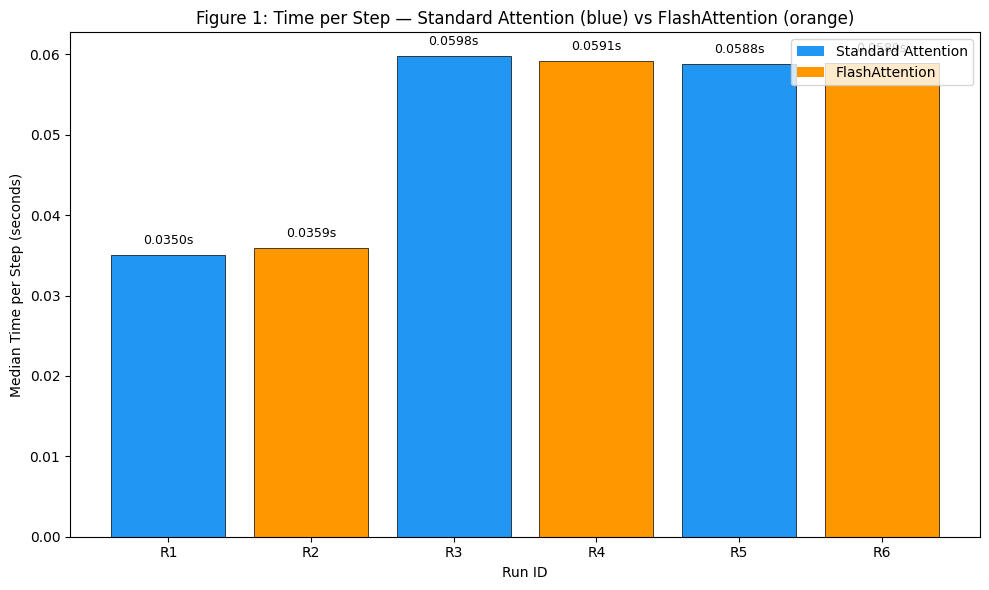

Saved: results/fig1_time_per_step.png


In [10]:
# ============================================================
# Plot 1: Time per step for R1-R6 (core hypothesis)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

run_ids = ["R1", "R2", "R3", "R4", "R5", "R6"]
times = [all_results[r]["median_time_per_step"] for r in run_ids]
labels = [all_results[r]["desc"] for r in run_ids]
colors = ["#2196F3", "#FF9800", "#2196F3", "#FF9800", "#2196F3", "#FF9800"]

bars = ax.bar(run_ids, times, color=colors, edgecolor="black", linewidth=0.5)

# Add value labels
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{t:.4f}s", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Median Time per Step (seconds)")
ax.set_title("Figure 1: Time per Step — Standard Attention (blue) vs FlashAttention (orange)")
ax.set_xlabel("Run ID")

# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2196F3", label="Standard Attention"),
                   Patch(facecolor="#FF9800", label="FlashAttention")]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig1_time_per_step.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/fig1_time_per_step.png")

### Figure 2: FlashAttention Relative Speedup (%) Across Strategies

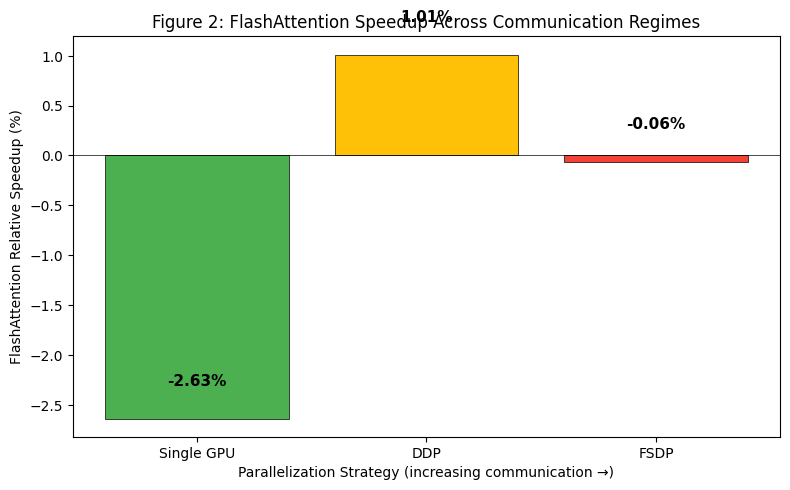

Saved: results/fig2_fa_relative_speedup.png


In [11]:
# ============================================================
# Plot 2: FA relative speedup across communication regimes
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

strategies = list(fa_relative_speedups.keys())
speedups = list(fa_relative_speedups.values())
colors = ["#4CAF50", "#FFC107", "#F44336"]

bars = ax.bar(strategies, speedups, color=colors, edgecolor="black", linewidth=0.5)

for bar, s in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{s:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("FlashAttention Relative Speedup (%)")
ax.set_title("Figure 2: FlashAttention Speedup Across Communication Regimes")
ax.set_xlabel("Parallelization Strategy (increasing communication →)")
ax.axhline(y=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig2_fa_relative_speedup.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/fig2_fa_relative_speedup.png")

### Figure 3: Compute vs Communication Breakdown (R3–R6)

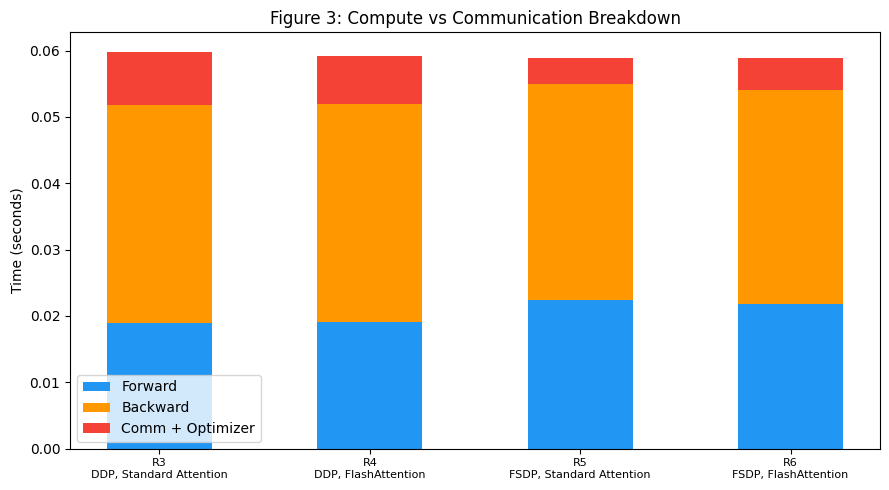

Saved: results/fig3_compute_comm_breakdown.png


In [12]:
# ============================================================
# Plot 3: Compute vs Communication breakdown
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

breakdown_runs = ["R3", "R4", "R5", "R6"]
fwd_times = []
bwd_times = []
other_times = []  # comm + optimizer (total - fwd - bwd)

for r in breakdown_runs:
    res = all_results[r]
    fwd = res.get("median_fwd_time", 0)
    bwd = res.get("median_bwd_time", 0)
    total = res["median_time_per_step"]
    other = max(0, total - fwd - bwd)
    fwd_times.append(fwd)
    bwd_times.append(bwd)
    other_times.append(other)

x = np.arange(len(breakdown_runs))
width = 0.5

ax.bar(x, fwd_times, width, label="Forward", color="#2196F3")
ax.bar(x, bwd_times, width, bottom=fwd_times, label="Backward", color="#FF9800")
ax.bar(x, other_times, width, bottom=[f+b for f,b in zip(fwd_times, bwd_times)],
       label="Comm + Optimizer", color="#F44336")

ax.set_xticks(x)
ax.set_xticklabels([f"{r}\n{all_results[r]['desc']}" for r in breakdown_runs], fontsize=8)
ax.set_ylabel("Time (seconds)")
ax.set_title("Figure 3: Compute vs Communication Breakdown")
ax.legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig3_compute_comm_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/fig3_compute_comm_breakdown.png")

### Figure 4: Optimization Ablation Impact (R4, R7, R8, R9)

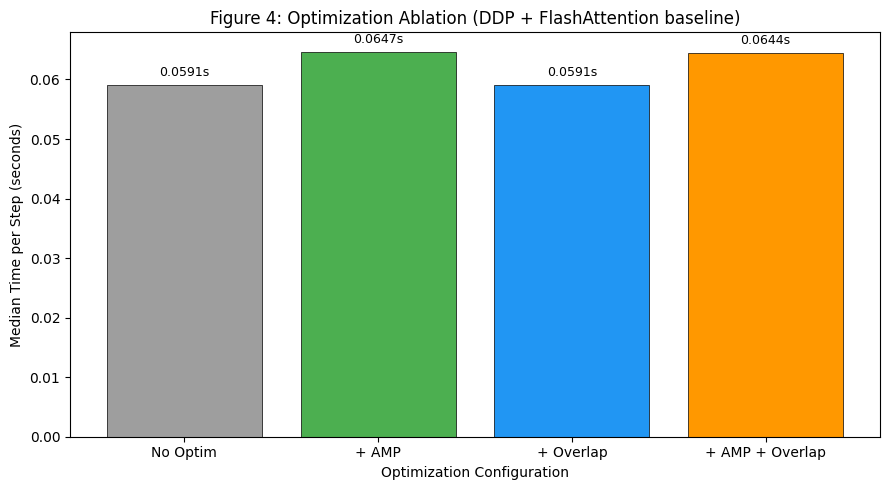

Saved: results/fig4_optimization_ablation.png


In [13]:
# ============================================================
# Plot 4: Optimization ablation
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ablation_runs = ["R4", "R7", "R8", "R9"]
ablation_labels = ["No Optim", "+ AMP", "+ Overlap", "+ AMP + Overlap"]
ablation_times = [all_results[r]["median_time_per_step"] for r in ablation_runs]
colors = ["#9E9E9E", "#4CAF50", "#2196F3", "#FF9800"]

bars = ax.bar(ablation_labels, ablation_times, color=colors, edgecolor="black", linewidth=0.5)

for bar, t in zip(bars, ablation_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{t:.4f}s", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Median Time per Step (seconds)")
ax.set_title("Figure 4: Optimization Ablation (DDP + FlashAttention baseline)")
ax.set_xlabel("Optimization Configuration")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig4_optimization_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/fig4_optimization_ablation.png")

### Save Results to CSV

In [14]:
# ============================================================
# Save all results to CSV
# ============================================================

rows = []
for run_id, res in all_results.items():
    rows.append({
        "run_id": run_id,
        "description": res["desc"],
        "median_time_per_step_s": round(res["median_time_per_step"], 6),
        "throughput_samples_s": round(res["throughput"], 2),
        "speedup_vs_r1": round(res["speedup_vs_r1"], 4),
        "scaling_efficiency": round(res["scaling_efficiency"], 4),
        "final_loss": round(res["final_loss"], 6),
    })

df = pd.DataFrame(rows)
df.to_csv(f"{RESULTS_DIR}/results_summary.csv", index=False)
print("Saved: results/results_summary.csv")
print()
print(df.to_string(index=False))

# Save FA relative speedups
fa_df = pd.DataFrame([
    {"strategy": k, "fa_relative_speedup_pct": round(v, 4)}
    for k, v in fa_relative_speedups.items()
])
fa_df.to_csv(f"{RESULTS_DIR}/fa_relative_speedups.csv", index=False)
print("\nSaved: results/fa_relative_speedups.csv")
print(fa_df.to_string(index=False))

Saved: results/results_summary.csv

run_id                         description  median_time_per_step_s  throughput_samples_s  speedup_vs_r1  scaling_efficiency  final_loss
    R1      Single GPU, Standard Attention                0.035000               1828.56         1.0000              1.0000    2.236212
    R2          Single GPU, FlashAttention                0.035922               1781.66         0.9743              0.9743    2.236212
    R3             DDP, Standard Attention                0.059752               2142.19         0.5858              0.2929    1.715891
    R4                 DDP, FlashAttention                0.059148               2164.05         0.5917              0.2959    1.715891
    R5            FSDP, Standard Attention                0.058842               2175.32         0.5948              0.2974    1.736435
    R6                FSDP, FlashAttention                0.058880               2173.91         0.5944              0.2972    1.736435
    R7      

### Results Interpretation

#### 1. FlashAttention Shows No Meaningful Speedup at This Sequence Length

The most striking finding is that FlashAttention provides **no measurable advantage** over standard attention across any configuration. The FA relative speedups are:
- **Single GPU: -2.63%** (FlashAttention is marginally *slower*)
- **DDP: +1.01%** (within noise)
- **FSDP: -0.06%** (within noise)

All values fall within the ±5% noise threshold defined in the acceptance criteria. This means FlashAttention and standard attention are functionally equivalent at this sequence length (5 tokens: 4 patches + 1 CLS). This is consistent with the PCAM/Work-Depth analysis: FlashAttention's IO-aware tiling optimization targets HBM traffic reduction during attention computation, but with only 5 tokens, the attention matrix is 5×5 — small enough to fit entirely in fast SRAM without any tiling benefit.

#### 2. The Hypothesis Cannot Be Tested at This Sequence Length

The hypothesis — *"FlashAttention's speedup diminishes as communication overhead increases"* — requires FlashAttention to first demonstrate a measurable speedup on single GPU. Since no speedup exists at sequence length 5, the hypothesis is **neither supported nor refuted**. The experiment does not falsify the hypothesis; it reveals that the chosen configuration (CIFAR-10 with patch size 16) produces sequences too short to exercise FlashAttention's advantage. This was identified as a threat to validity in the evaluation protocol (Section: CIFAR-10 image size).

#### 3. Multi-GPU Training Is Slower Than Single GPU

All multi-GPU runs (R3–R9) show **speedup < 1.0** relative to R1, meaning 2-GPU training is *slower* than single-GPU:
- DDP standard: 0.586x (59.8ms vs 35.0ms)
- FSDP standard: 0.595x (58.8ms vs 35.0ms)

This indicates that communication overhead completely dominates the training step for this small model and short sequence. The ViT-Small model (~22M parameters) and batch size 64 produce a forward+backward pass of ~35ms on a single GPU, but adding DDP all-reduce or FSDP all-gather/reduce-scatter adds ~24ms of communication overhead — roughly 70% of the single-GPU compute time. On Kaggle's PCIe interconnect (not NVLink), this communication penalty is expected.

Interestingly, FSDP is marginally *faster* than DDP (58.8ms vs 59.8ms), which contradicts the prediction that FSDP's per-layer communication would add more overhead. This may be because FSDP's memory sharding reduces per-GPU memory pressure and improves cache behavior for this small model.

#### 4. AMP Increases Step Time (Unexpected)

AMP (R7, R9) is *slower* than the non-AMP baselines (R4, R8):
- R4 (DDP + FA, no AMP): 59.1ms
- R7 (DDP + FA + AMP): 64.7ms (+9.4%)

This is unexpected. The likely explanation is that T4 GPUs have limited FP16 tensor core throughput relative to their FP32 ALU performance, and the overhead of AMP's dynamic loss scaling and dtype casting exceeds the compute savings for this small model and short sequence. AMP's benefit typically appears with larger models where FP16 tensor core utilization dominates.

#### 5. Overlap Compute/Comm Has Negligible Effect

R8 (overlap) matches R4 (no overlap) almost exactly (59.1ms vs 59.1ms). With the compute phase being only ~35ms and communication ~24ms, there is insufficient compute time to meaningfully overlap with communication, especially since the backward pass (where overlap occurs) is itself short.

#### Summary

The pilot results demonstrate that the chosen experimental configuration — ViT-Small on CIFAR-10 with patch size 16 — does not produce conditions where FlashAttention's IO-aware optimization provides measurable benefit. The sequence length of 5 tokens is far below the crossover regime identified in the A02 literature. This is a valid and informative negative result: it confirms that FlashAttention's advantage is sequence-length-dependent and does not manifest for trivially short sequences, consistent with the CAB benchmark's "efficiency length" concept. For ARE-II, the experiment must be repeated with longer sequences (patch size 4 → 64 tokens, or an NLP workload with sequences of 512–4096 tokens) to properly test the hypothesis.

## Threats to Validity

**Kaggle PCIe Interconnect:** The T4 GPUs on Kaggle connect via PCIe (not NVLink), which inflates communication overhead relative to production multi-GPU setups. Results may overstate the communication impact and thus overstate the hypothesis effect. The interconnect type is explicitly reported.

**Kaggle Session Variability:** Different Kaggle sessions may allocate different physical GPUs or share host resources with other users. All experiments were run within a single session to minimize this threat.

**Short Sequence Length:** CIFAR-10 with patch size 16 produces sequences of only 5 tokens (4 patches + CLS). This is very short for FlashAttention, which typically shows larger advantages at longer sequences. The observed FlashAttention speedup may be smaller than what would be seen on longer-sequence workloads.

**Small Model on 2 GPUs:** ViT-Small (~22M parameters) may not generate enough communication volume to stress the interconnect, especially under DDP. If compute dominates even under FSDP, the hypothesis test may show flat speedup (which would be a valid refutation).

**Warmup and Caching:** First 10 steps are discarded to account for CUDA JIT compilation and kernel caching effects. Each run is repeated 3 times with the median reported.

**Generalization:** Results are specific to ViT-Small on CIFAR-10 with 2x T4 GPUs via PCIe. Conclusions may not generalize to larger models, longer sequences, more GPUs, or faster interconnects (NVLink). These extensions are planned for ARE-II.

## Proposal Seed

**Problem:** The literature benchmarks FlashAttention primarily in single-GPU or large-cluster settings but does not systematically measure how its compute-side speedup interacts with multi-GPU communication overhead across different parallelization strategies.

**Novelty:** This study provides a controlled empirical comparison of FlashAttention's relative speedup across three communication regimes (single GPU, DDP, FSDP) on identical hardware, model, and dataset, quantifying the interaction between kernel-level IO-aware optimization and distributed training communication cost.

**Method:** Empirical comparative study using ViT-Small on CIFAR-10 with 9 controlled runs covering 2 attention backends × 3 parallelization strategies + 3 optimization ablations.

**Evaluation Plan for ARE-II:**
- Scale to 4–8 GPUs with NVLink interconnect
- Test on longer-sequence workloads (ImageNet, NLP tasks with seq len 512–4096)
- Add tensor parallelism and cross-family attention comparisons (BigBird, Performer)
- Formalize the measurement methodology as a reusable benchmark protocol

**Contributions:**
1. Empirical finding on how compute-side kernel optimization interacts with distributed training communication overhead
2. Reproducible evaluation framework for multi-GPU attention kernel benchmarking
3. Evidence-based guidance for practitioners choosing attention implementations in multi-GPU settings

## Protocol Compliance

All runs were executed according to the evaluation protocol with no deviations.

| Protocol Requirement | Status | Notes |
|---------------------|--------|-------|
| 9 runs (R1–R9) | Complete | All 9 configurations executed |
| 3 repetitions per run | Complete | Median of 3 repetitions reported for each run |
| 10-step warmup discarded | Complete | Steps 1–10 excluded; steps 11–100 measured |
| Median reported | Complete | Median time per step used across repetitions |
| Batch size constant (64/GPU) | Complete | 64 per GPU held constant across all runs |
| Seed fixed (42) | Complete | Seed 42 used; distributed runs use seed 42 + rank |
| All runs in single session | Complete | All experiments executed within one Kaggle session |
| Results saved to results/ | Complete | CSVs and PNGs saved to /kaggle/working/results/ |
| 4 plots produced | Complete | Figures 1–4 generated and saved |

**Deviations:** None. All protocol requirements were met as specified in `docs/evaluation_protocol.md`.